# 02 — Feature Engineering: Growth & Video Context (Wildan)
**Tujuan:** Membuat fitur-fitur pertumbuhan views antar periode (ts1→ts4), konteks video (umur, kecepatan, viral), dan fitur temporal upload.  
**Output:** `data/processed/features_growth.csv`  
**Digunakan oleh:** M1-Regression, M3-Anomaly, M4-RootCause, M5-Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
DATA_PATH = '../../data/cleaned/abis_cleaning.csv'
df = pd.read_csv(DATA_PATH)
df = df.drop_duplicates(subset=['video_id'], keep='first').reset_index(drop=True)

# Column aliases
df['views'] = df['penayangan_tak_dilewati']
df['watch_time_hours'] = df['waktu_tonton_jam']
df['subscribers'] = df['subscriber']
df['subscriber_gained'] = df['subscriber_yang_diperoleh']
df['subscriber_lost']   = df['subscriber_yang_hilang']

def time_to_sec(t):
    try:
        if pd.isna(t): return 0
        parts = str(t).split(':')
        if len(parts)==3: return int(parts[0])*3600+int(parts[1])*60+int(parts[2])
        if len(parts)==2: return int(parts[0])*60+int(parts[1])
        return float(t)
    except: return 0

df['video_duration_sec'] = df['durasi']
df['average_view_duration_sec'] = df['rata_rata_durasi_tonton'].apply(time_to_sec)

print(f"Shape: {df.shape}")
print(f"Kolom tersedia: {list(df.columns)}")

Shape: (2355, 55)
Kolom tersedia: ['video_id', 'judul_video', 'waktu_publikasi_video', 'durasi', 'penayangan_tak_dilewati', 'pendapatan_transaksi_idr', 'estimasi_pendapatan_adsense_idr', 'estimasi_pendapatan_doubleclick_idr', 'subscriber_yang_diperoleh', 'subscriber_yang_hilang', 'suka', 'tidak_suka', 'komentar_ditambahkan', 'persentase_penayangan_rata_rata', 'youtube_premium_idr', 'iklan_halaman_tonton_idr', 'pendapatan_iklan_youtube_idr', 'tayangan_iklan', 'cpm_idr', 'rpm_idr', 'waktu_tonton_youtube_premium_jam', 'penayangan_youtube_premium', 'waktu_tonton_dari_klip_komunitas_jam', 'penayangan_klip_komunitas', 'jumlah_klik_pada_kartu', 'kartu_ditampilkan', 'jumlah_klik_pada_teaser_kartu', 'teaser_kartu_ditampilkan', 'klik_teaser_per_teaser_kartu_yang_ditampilkan', 'klik_per_elemen_layar_akhir_yang_ditampilkan', 'elemen_layar_akhir_yang_ditampilkan', 'klik_pada_elemen_layar_akhir', 'penayangan', 'waktu_tonton_jam', 'subscriber', 'estimasi_pendapatan_idr', 'rata_rata_durasi_tonton', 't

=== STATISTIK DASAR ===
            views  ts1_views  ts2_views  ts3_views   ts4_views  \
count     2355.00    2350.00    2350.00    2350.00     2350.00   
mean     42805.18   20045.16   24748.95   29210.36    34631.55   
std      95498.31   38077.67   48494.23   58874.12    74939.15   
min         19.00       2.00       2.00       2.00        2.00   
25%       4915.00    2699.25    3439.75    3860.25     4118.75   
50%      12755.00    6909.50    8640.50   10114.50    10835.00   
75%      37527.00   19560.00   24247.50   28550.25    31906.25   
max    1515626.00  386070.00  640783.00  907195.00  1174132.00   

       watch_time_hours  video_duration_sec  
count           2355.00             2355.00  
mean            2830.91              645.97  
std             7291.45             1502.40  
min                0.61               14.00  
25%              253.35              531.50  
50%              733.42              572.00  
75%             2279.51              630.00  
max          

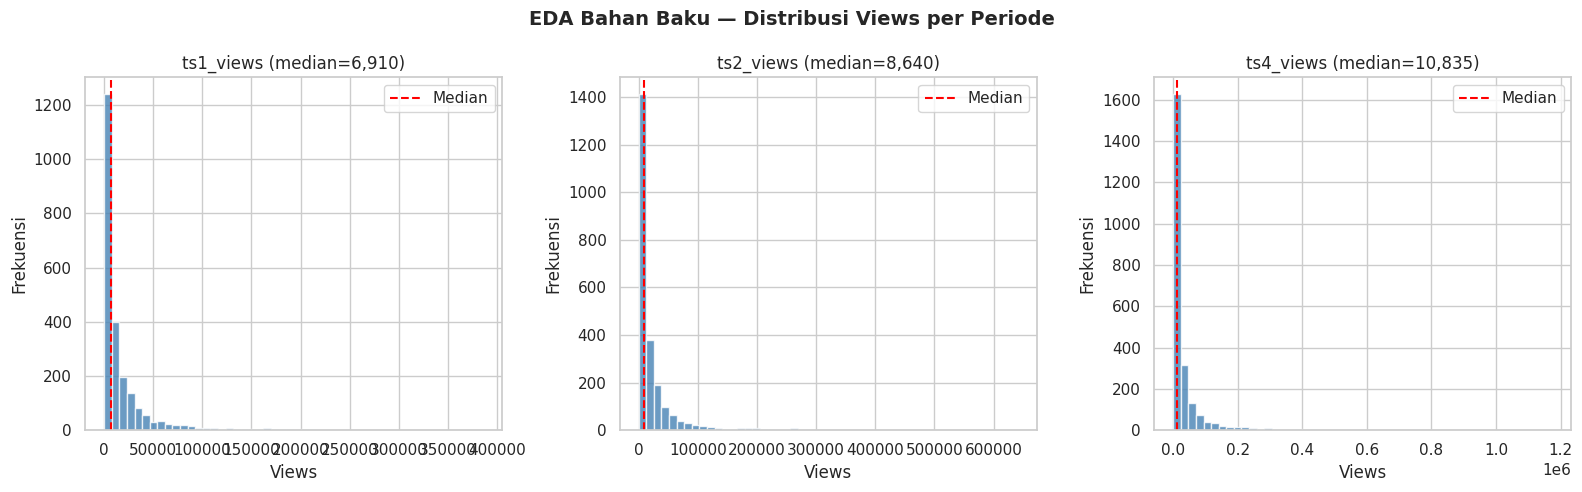

In [3]:
# ── 2. EDA BAHAN BAKU ────────────────────────────────────────────────────────
print("=== STATISTIK DASAR ===")
print(df[['views','ts1_views','ts2_views','ts3_views','ts4_views',
          'watch_time_hours','video_duration_sec']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA Bahan Baku — Distribusi Views per Periode', fontsize=14, fontweight='bold')

for i, col in enumerate(['ts1_views','ts2_views','ts4_views']):
    vals = df[col].dropna()
    axes[i].hist(vals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} (median={vals.median():,.0f})')
    axes[i].set_xlabel('Views')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(vals.median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [4]:
# ── 3. FEATURE: GROWTH RATE ANTAR PERIODE ────────────────────────────────────
# Aman dari data leakage: semua ts sudah tersedia di saat prediksi
ts_safe = {
    'ts1': df['ts1_views'].replace(0, np.nan),
    'ts2': df['ts2_views'].replace(0, np.nan),
    'ts3': df['ts3_views'].replace(0, np.nan),
}
df['growth_1_to_2'] = ((df['ts2_views'] - df['ts1_views']) / ts_safe['ts1'] * 100).clip(-300, 300).fillna(0)
df['growth_2_to_3'] = ((df['ts3_views'] - df['ts2_views']) / ts_safe['ts2'] * 100).clip(-300, 300).fillna(0)
df['growth_3_to_4'] = ((df['ts4_views'] - df['ts3_views']) / ts_safe['ts3'] * 100).clip(-300, 300).fillna(0)

df['avg_growth_rate']  = df[['growth_1_to_2','growth_2_to_3','growth_3_to_4']].mean(axis=1)
df['growth_trend']     = df['growth_3_to_4'] - df['growth_1_to_2']   # akselerasi/deselerasi
df['peak_views']       = df[['ts1_views','ts2_views','ts3_views','ts4_views']].max(axis=1)
df['views_volatility'] = df[['ts1_views','ts2_views','ts3_views','ts4_views']].std(axis=1).fillna(0)

print("Growth features computed ✓")
df[['growth_1_to_2','growth_2_to_3','growth_3_to_4','avg_growth_rate','growth_trend']].describe().round(2)

Growth features computed ✓


,growth_1_to_2,growth_2_to_3,growth_3_to_4,avg_growth_rate,growth_trend
count,2355.00,2355.00,2355.00,2355.00,2355.00
mean,28.99,17.69,10.64,19.10,-18.36
std,40.52,34.59,24.81,25.97,43.27
min,0.00,0.00,0.00,0.00,-299.95
25%,8.05,2.92,1.01,5.03,-25.19
50%,16.05,6.79,2.60,10.00,-9.96
75%,33.28,16.83,8.36,22.06,-2.91
max,300.00,300.00,300.00,286.28,295.92


In [5]:
# ── 4. FEATURE: TEMPORAL UPLOAD ──────────────────────────────────────────────
df['publish_date'] = pd.to_datetime(df['tanggal_upload'], errors='coerce')
TODAY = df['publish_date'].max() + pd.Timedelta(days=1)

df['video_age_days'] = (TODAY - df['publish_date']).dt.days.clip(lower=1)
df['day_of_week']    = df['publish_date'].dt.dayofweek   # 0=Mon … 6=Sun
df['month']          = df['publish_date'].dt.month
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)

# View velocity: views per day (anti-leak: menggunakan video_age)
df['view_velocity'] = (df['views'] / df['video_age_days']).round(2)

print("Temporal features computed ✓")
print(df[['video_age_days','day_of_week','month','view_velocity']].describe().round(2))

Temporal features computed ✓
       video_age_days  day_of_week    month  view_velocity
count         2355.00      2355.00  2355.00        2355.00
mean           223.09         2.99     6.15         223.31
std            134.93         2.01     3.75         550.25
min              1.00         0.00     1.00           0.16
25%            106.00         1.00     3.00          36.03
50%            221.00         3.00     6.00          85.76
75%            328.00         5.00    10.00         211.63
max            487.00         6.00    12.00       13898.00


In [6]:
# ── 5. FEATURE: VIRAL & CHANNEL BENCHMARK ────────────────────────────────────
channel_avg_views = df['views'].mean()
df['views_vs_channel_avg'] = (df['views'] / (channel_avg_views + 1)).round(4)

# is_viral: top 10% views
viral_threshold = df['views'].quantile(0.90)
df['is_viral']         = (df['views'] >= viral_threshold).astype(int)
df['is_top_performer'] = (df['views'] >= df['views'].quantile(0.75)).astype(int)

# Subscriber balance
df['subscriber_net'] = df['subscriber_gained'] - df['subscriber_lost'].abs()

print(f"Channel avg views: {channel_avg_views:,.0f}")
print(f"Viral threshold (90th pct): {viral_threshold:,.0f}")
print(f"Jumlah video viral: {df['is_viral'].sum()} ({df['is_viral'].mean()*100:.1f}%)")

Channel avg views: 42,805
Viral threshold (90th pct): 105,333
Jumlah video viral: 236 (10.0%)


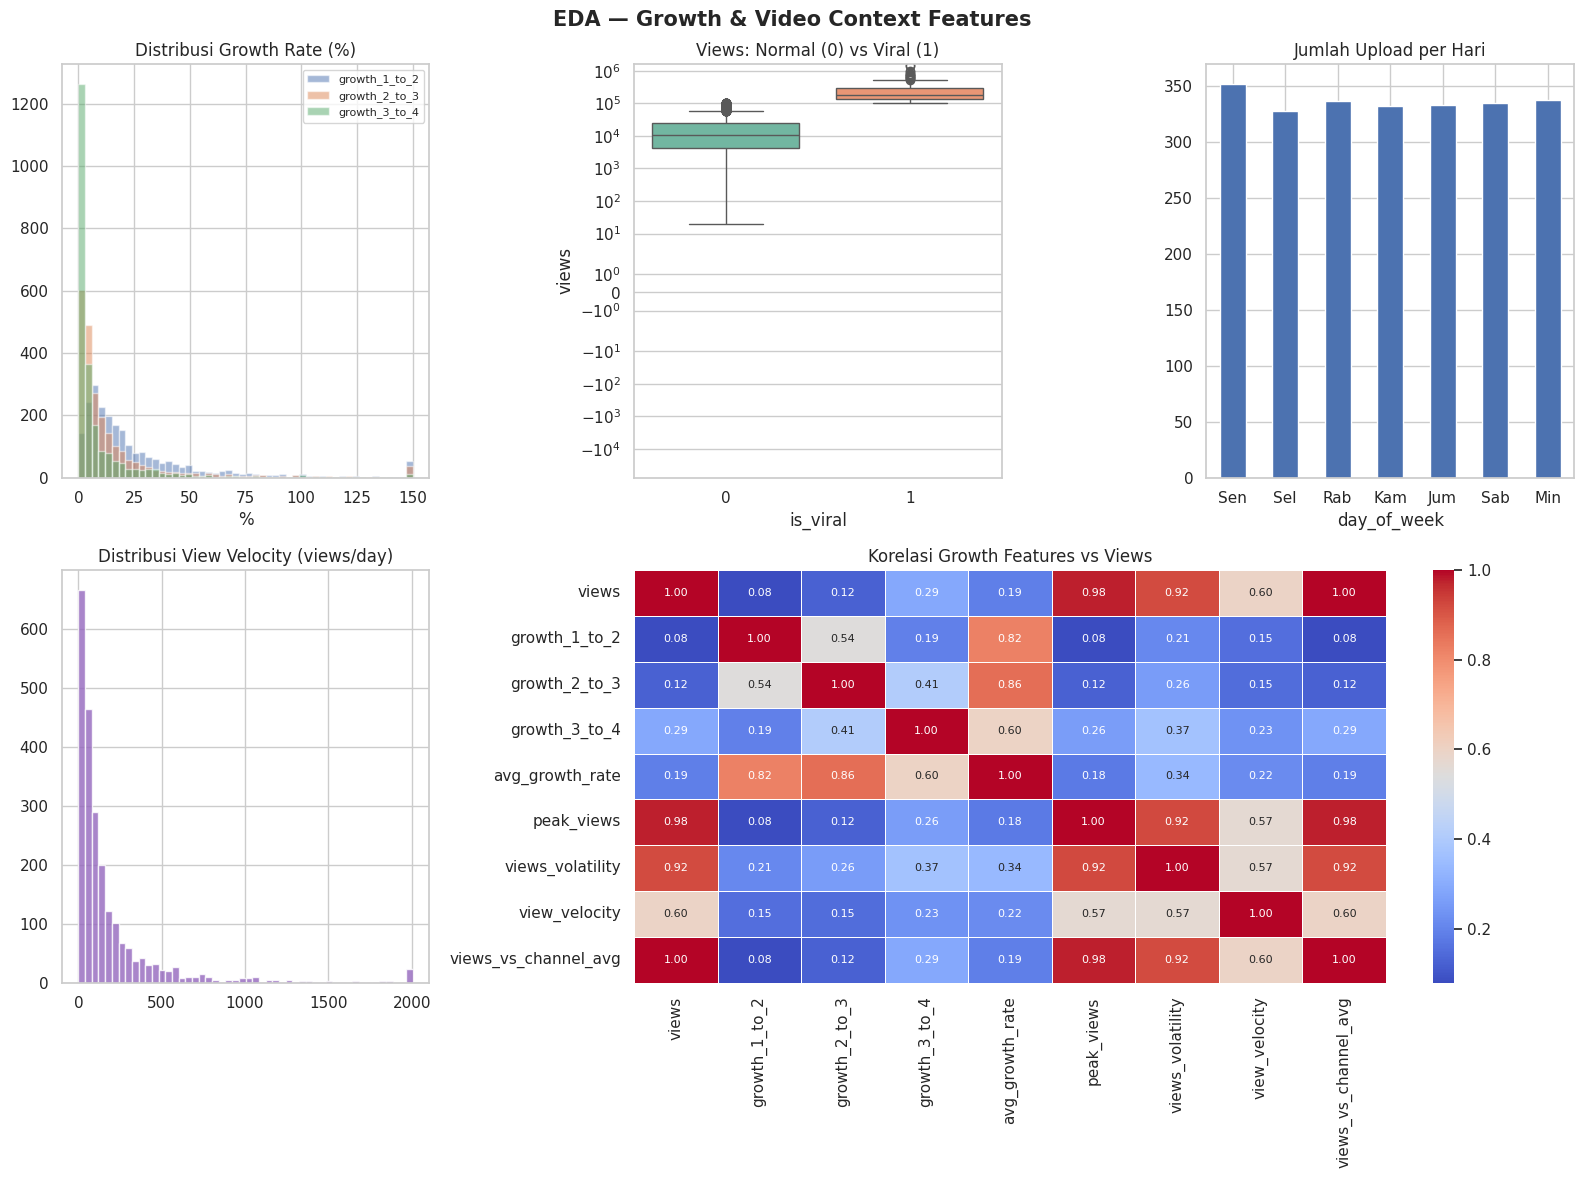

In [7]:
# ── 6. EDA GROWTH FEATURES ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('EDA — Growth & Video Context Features', fontsize=15, fontweight='bold')

# (A) Distribusi growth rates
ax1 = fig.add_subplot(gs[0, 0])
for col, c in [('growth_1_to_2','#4C72B0'),('growth_2_to_3','#DD8452'),('growth_3_to_4','#55A868')]:
    ax1.hist(df[col].clip(-150,150), bins=50, alpha=0.5, label=col, color=c)
ax1.set_title('Distribusi Growth Rate (%)'); ax1.set_xlabel('%'); ax1.legend(fontsize=8)

# (B) Viral vs Non-Viral — views distribution
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df, x='is_viral', y='views', palette='Set2', ax=ax2)
ax2.set_yscale('symlog'); ax2.set_title('Views: Normal (0) vs Viral (1)')

# (C) Upload day distribution
ax3 = fig.add_subplot(gs[0, 2])
day_labels = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
df['day_of_week'].value_counts().sort_index().plot(kind='bar', ax=ax3, color='#4C72B0', edgecolor='white')
ax3.set_title('Jumlah Upload per Hari'); ax3.set_xticklabels(day_labels, rotation=0)

# (D) View velocity distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['view_velocity'].clip(0, df['view_velocity'].quantile(0.99)), bins=50, color='#9467BD', edgecolor='white', alpha=0.8)
ax4.set_title('Distribusi View Velocity (views/day)')

# (E) Correlation heatmap
ax5 = fig.add_subplot(gs[1, 1:])
feat_corr = ['views','growth_1_to_2','growth_2_to_3','growth_3_to_4',
             'avg_growth_rate','peak_views','views_volatility','view_velocity','views_vs_channel_avg']
corr = df[feat_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax5, linewidths=0.5, annot_kws={'size':8})
ax5.set_title('Korelasi Growth Features vs Views')

plt.tight_layout()
plt.show()

In [8]:
# ── 7. VALIDASI FITUR ────────────────────────────────────────────────────────
growth_cols = [
    'video_id','growth_1_to_2','growth_2_to_3','growth_3_to_4',
    'avg_growth_rate','growth_trend','peak_views','views_volatility',
    'view_velocity','video_age_days','day_of_week','month','is_weekend',
    'views_vs_channel_avg','is_viral','is_top_performer',
    'subscriber_net','watch_time_hours','video_duration_sec','views'
]
df_final = df[growth_cols].copy()

print("=== VALIDASI OUTPUT ===")
print(f"Shape : {df_final.shape}")
print(f"Nulls  : {df_final.isnull().sum().sum()}")
print("\nSampel:")
display(df_final.head(3))

=== VALIDASI OUTPUT ===
Shape : (2355, 20)
Nulls  : 5

Sampel:


,video_id,growth_1_to_2,growth_2_to_3,growth_3_to_4,avg_growth_rate,growth_trend,peak_views,views_volatility,view_velocity,video_age_days,day_of_week,month,is_weekend,views_vs_channel_avg,is_viral,is_top_performer,subscriber_net,watch_time_hours,video_duration_sec,views
0,jkL6Ii5d4hI,27.128269,6.035312,13.831068,15.664883,-13.297202,283708.0,41005.832410,1389.40,314,4,5,0,10.1918,1,1,1344,26362.9304,541.0,436273
1,mIeRGD4KT-A,21.175654,19.509819,47.652031,29.445835,26.476377,298861.0,69085.574743,1149.84,330,2,5,0,8.8643,1,1,1380,24203.8942,540.0,379446
2,XCRg3dGQqd8,18.690817,8.143909,11.239723,12.691483,-7.451094,293882.0,36942.991203,1044.01,334,5,5,1,8.1460,1,1,978,19730.7862,637.0,348698


In [9]:
# ── 8. EXPORT ─────────────────────────────────────────────────────────────────
import os
output_path = '../../data/processed/features_growth.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_final.to_csv(output_path, index=False)
print(f"✅ Tersimpan: {output_path}")
print(f"   Shape: {df_final.shape}")
print(f"   Kolom: {list(df_final.columns)}")

✅ Tersimpan: ../../data/processed/features_growth.csv
   Shape: (2355, 20)
   Kolom: ['video_id', 'growth_1_to_2', 'growth_2_to_3', 'growth_3_to_4', 'avg_growth_rate', 'growth_trend', 'peak_views', 'views_volatility', 'view_velocity', 'video_age_days', 'day_of_week', 'month', 'is_weekend', 'views_vs_channel_avg', 'is_viral', 'is_top_performer', 'subscriber_net', 'watch_time_hours', 'video_duration_sec', 'views']
